# GAN Implementation

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch

In [2]:
!pip install torchvision

In [3]:
import torch
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [4]:
# images load => transform => dataset of all imgs
class ImageProcessor:
    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        # list of paths for all images
        self.all_img_paths = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img

In [5]:
root_dir_path = "./img_align_celeba"

transformations = transforms.Compose([
    transforms.CenterCrop(178), # 178x218 => 178x178
    transforms.Resize(64), # 64x64
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1]
])

In [6]:
dataset = ImageProcessor(root_dir_path, transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [7]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Genrative Network

In [8]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [9]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): # 3 is for RGB
        super(Generator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256
            nn.ReLU(),

            nn.Linear(256, 512), 
            nn.ReLU(),

            nn.Linear(512, 1024), 
            nn.ReLU(),

            nn.Linear(1024, 64 * 64 * img_channels), 
            nn.Tanh() # [-1, 1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64) 
        return img

        # fake img => 64 x 64 x 3 x batch_size

# Descrimination Network

In [10]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3): # 3 is for RGB
        super(Discriminator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), # 4D tensor => 1D
            
            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1), 
            nn.Sigmoid() # probability of being real/fake 
        )

    def forward(self, img):
        return self.model(img)

In [11]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [12]:
import torch
# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device is {device}")

device is cuda


In [13]:
generator = generator.to(device)
discriminator = discriminator.to(device)

# Training the GAN

In [14]:
def train(generator, discriminator, dataloader, epochs=10):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1, 1, 1....]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0, 0, 0....]

            # Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size, 100).to(device))

            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the Generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}... G-loss:{g_loss}.... D-loss: {d_loss}")

        # save generated imgs for each epoch
        save_generated_images(generator, epoch, device) 

In [15]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch: 1/20... batch: 1... G-loss:1.7845467329025269.... D-loss: 0.4755794405937195
for epoch: 1/20... batch: 51... G-loss:1.7662560939788818.... D-loss: 0.4257315397262573
for epoch: 1/20... batch: 101... G-loss:1.5384578704833984.... D-loss: 0.5069260597229004
for epoch: 1/20... batch: 151... G-loss:1.6797432899475098.... D-loss: 0.46671074628829956
for epoch: 1/20... batch: 201... G-loss:1.8166981935501099.... D-loss: 0.4750727415084839
for epoch: 1/20... batch: 251... G-loss:1.8551690578460693.... D-loss: 0.5751852989196777
for epoch: 1/20... batch: 301... G-loss:1.75572669506073.... D-loss: 0.5394449234008789
for epoch: 1/20... batch: 351... G-loss:1.765427827835083.... D-loss: 0.4663912355899811
for epoch: 1/20... batch: 401... G-loss:1.450937032699585.... D-loss: 0.502615213394165
for epoch: 1/20... batch: 451... G-loss:1.7632098197937012.... D-loss: 0.5043336749076843
for epoch: 1/20... batch: 501... G-loss:1.8379840850830078.... D-loss: 0.44172441959381104
for epoch: 1/20.

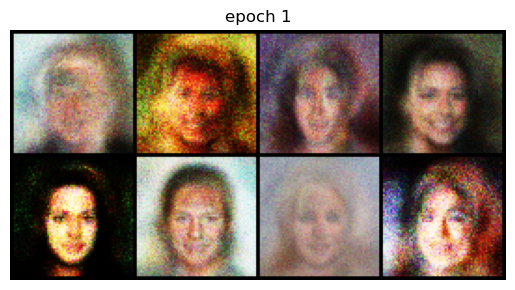

for epoch: 2/20... batch: 1... G-loss:1.7401831150054932.... D-loss: 0.6036306619644165
for epoch: 2/20... batch: 51... G-loss:1.7086710929870605.... D-loss: 0.6067637801170349
for epoch: 2/20... batch: 101... G-loss:1.5052862167358398.... D-loss: 0.5570892095565796
for epoch: 2/20... batch: 151... G-loss:1.312680959701538.... D-loss: 0.6193351745605469
for epoch: 2/20... batch: 201... G-loss:1.4670805931091309.... D-loss: 0.4955388605594635
for epoch: 2/20... batch: 251... G-loss:1.2416616678237915.... D-loss: 0.5384461283683777
for epoch: 2/20... batch: 301... G-loss:1.3525879383087158.... D-loss: 0.5448678135871887
for epoch: 2/20... batch: 351... G-loss:1.5450892448425293.... D-loss: 0.5743298530578613
for epoch: 2/20... batch: 401... G-loss:1.301375150680542.... D-loss: 0.5702245831489563
for epoch: 2/20... batch: 451... G-loss:1.553149938583374.... D-loss: 0.626998782157898
for epoch: 2/20... batch: 501... G-loss:1.4692988395690918.... D-loss: 0.5422226786613464
for epoch: 2/20..

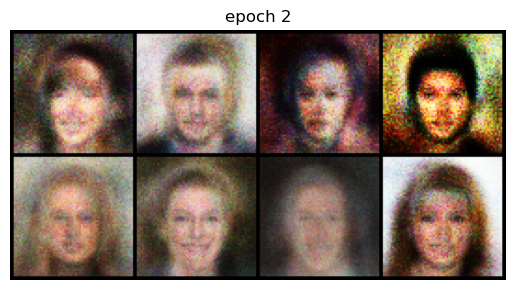

for epoch: 3/20... batch: 1... G-loss:1.4756665229797363.... D-loss: 0.4898279011249542
for epoch: 3/20... batch: 51... G-loss:1.4000093936920166.... D-loss: 0.609704852104187
for epoch: 3/20... batch: 101... G-loss:1.5288927555084229.... D-loss: 0.5394604206085205
for epoch: 3/20... batch: 151... G-loss:1.2417755126953125.... D-loss: 0.5223640203475952
for epoch: 3/20... batch: 201... G-loss:1.3688502311706543.... D-loss: 0.5657148361206055
for epoch: 3/20... batch: 251... G-loss:1.337141513824463.... D-loss: 0.5237655639648438
for epoch: 3/20... batch: 301... G-loss:1.4847385883331299.... D-loss: 0.5014690160751343
for epoch: 3/20... batch: 351... G-loss:1.526792049407959.... D-loss: 0.571776270866394
for epoch: 3/20... batch: 401... G-loss:1.4383292198181152.... D-loss: 0.578294038772583
for epoch: 3/20... batch: 451... G-loss:1.479000449180603.... D-loss: 0.611882209777832
for epoch: 3/20... batch: 501... G-loss:1.579756498336792.... D-loss: 0.5549167394638062
for epoch: 3/20... ba

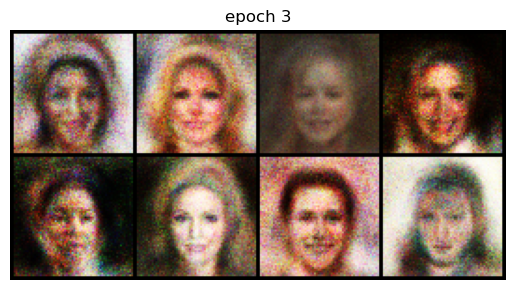

for epoch: 4/20... batch: 1... G-loss:1.5436818599700928.... D-loss: 0.6040295362472534
for epoch: 4/20... batch: 51... G-loss:1.5621228218078613.... D-loss: 0.5084037780761719
for epoch: 4/20... batch: 101... G-loss:1.4439256191253662.... D-loss: 0.5268868803977966
for epoch: 4/20... batch: 151... G-loss:1.3256478309631348.... D-loss: 0.5773619413375854
for epoch: 4/20... batch: 201... G-loss:1.2934372425079346.... D-loss: 0.5433118939399719
for epoch: 4/20... batch: 251... G-loss:1.3483651876449585.... D-loss: 0.5628433227539062
for epoch: 4/20... batch: 301... G-loss:1.248393177986145.... D-loss: 0.6025566458702087
for epoch: 4/20... batch: 351... G-loss:1.48298180103302.... D-loss: 0.5403802394866943
for epoch: 4/20... batch: 401... G-loss:1.462609887123108.... D-loss: 0.503601610660553
for epoch: 4/20... batch: 451... G-loss:1.3431625366210938.... D-loss: 0.5845747590065002
for epoch: 4/20... batch: 501... G-loss:1.2368109226226807.... D-loss: 0.5638713240623474
for epoch: 4/20...

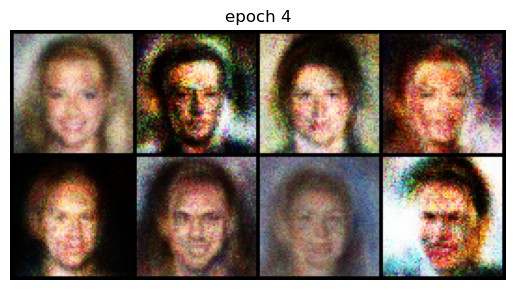

for epoch: 5/20... batch: 1... G-loss:1.3933985233306885.... D-loss: 0.5778957605361938
for epoch: 5/20... batch: 51... G-loss:1.349739670753479.... D-loss: 0.6144622564315796
for epoch: 5/20... batch: 101... G-loss:1.1840392351150513.... D-loss: 0.5760395526885986
for epoch: 5/20... batch: 151... G-loss:1.1960246562957764.... D-loss: 0.5848326683044434
for epoch: 5/20... batch: 201... G-loss:1.1900880336761475.... D-loss: 0.5820469856262207
for epoch: 5/20... batch: 251... G-loss:1.3532214164733887.... D-loss: 0.5523989796638489
for epoch: 5/20... batch: 301... G-loss:1.1718673706054688.... D-loss: 0.6003877520561218
for epoch: 5/20... batch: 351... G-loss:1.231407642364502.... D-loss: 0.5754278898239136
for epoch: 5/20... batch: 401... G-loss:1.3533809185028076.... D-loss: 0.550013542175293
for epoch: 5/20... batch: 451... G-loss:1.1827781200408936.... D-loss: 0.6125554442405701
for epoch: 5/20... batch: 501... G-loss:1.3005727529525757.... D-loss: 0.5818983316421509
for epoch: 5/20.

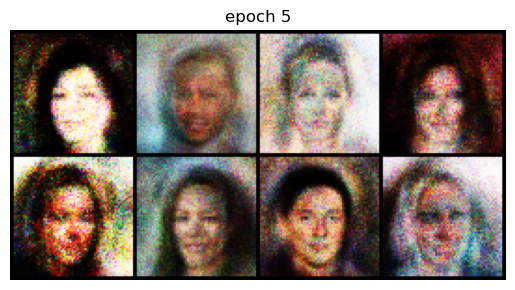

for epoch: 6/20... batch: 1... G-loss:1.1435866355895996.... D-loss: 0.5807773470878601
for epoch: 6/20... batch: 51... G-loss:1.373520851135254.... D-loss: 0.546148419380188
for epoch: 6/20... batch: 101... G-loss:1.1440422534942627.... D-loss: 0.6081966161727905
for epoch: 6/20... batch: 151... G-loss:1.1680028438568115.... D-loss: 0.5923020839691162
for epoch: 6/20... batch: 201... G-loss:1.2843279838562012.... D-loss: 0.573977530002594
for epoch: 6/20... batch: 251... G-loss:1.2768690586090088.... D-loss: 0.5825506448745728
for epoch: 6/20... batch: 301... G-loss:1.1388142108917236.... D-loss: 0.5907531380653381
for epoch: 6/20... batch: 351... G-loss:1.263488531112671.... D-loss: 0.596601128578186
for epoch: 6/20... batch: 401... G-loss:1.3209354877471924.... D-loss: 0.5797858238220215
for epoch: 6/20... batch: 451... G-loss:1.2285377979278564.... D-loss: 0.5582784414291382
for epoch: 6/20... batch: 501... G-loss:1.4049655199050903.... D-loss: 0.6029645204544067
for epoch: 6/20...

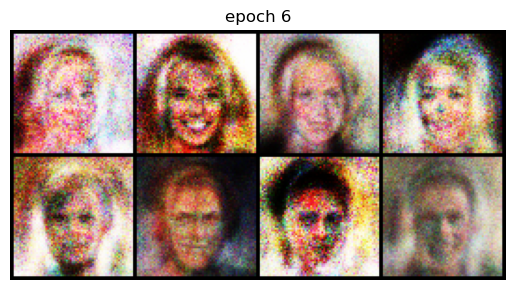

for epoch: 7/20... batch: 1... G-loss:1.1588034629821777.... D-loss: 0.5717113018035889
for epoch: 7/20... batch: 51... G-loss:1.2027103900909424.... D-loss: 0.5874371528625488
for epoch: 7/20... batch: 101... G-loss:1.131554365158081.... D-loss: 0.6066094040870667
for epoch: 7/20... batch: 151... G-loss:1.207202672958374.... D-loss: 0.5929309129714966
for epoch: 7/20... batch: 201... G-loss:1.2517820596694946.... D-loss: 0.586696982383728
for epoch: 7/20... batch: 251... G-loss:1.299535870552063.... D-loss: 0.6320042014122009
for epoch: 7/20... batch: 301... G-loss:1.2034186124801636.... D-loss: 0.6137166023254395
for epoch: 7/20... batch: 351... G-loss:1.200016975402832.... D-loss: 0.5539513826370239
for epoch: 7/20... batch: 401... G-loss:1.2413525581359863.... D-loss: 0.6342548131942749
for epoch: 7/20... batch: 451... G-loss:1.2492990493774414.... D-loss: 0.5963313579559326
for epoch: 7/20... batch: 501... G-loss:1.1064282655715942.... D-loss: 0.6349483728408813
for epoch: 7/20...

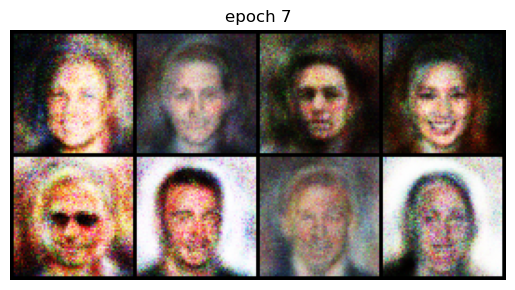

for epoch: 8/20... batch: 1... G-loss:1.27895987033844.... D-loss: 0.6118127107620239
for epoch: 8/20... batch: 51... G-loss:1.288784384727478.... D-loss: 0.5919903516769409
for epoch: 8/20... batch: 101... G-loss:1.1634495258331299.... D-loss: 0.6510983109474182
for epoch: 8/20... batch: 151... G-loss:1.0847675800323486.... D-loss: 0.6364267468452454
for epoch: 8/20... batch: 201... G-loss:1.1672478914260864.... D-loss: 0.5833708047866821
for epoch: 8/20... batch: 251... G-loss:1.0958912372589111.... D-loss: 0.6324127316474915
for epoch: 8/20... batch: 301... G-loss:1.25264573097229.... D-loss: 0.6163609027862549
for epoch: 8/20... batch: 351... G-loss:1.1601814031600952.... D-loss: 0.6083934307098389
for epoch: 8/20... batch: 401... G-loss:1.0889132022857666.... D-loss: 0.5909715890884399
for epoch: 8/20... batch: 451... G-loss:1.2225487232208252.... D-loss: 0.5686746835708618
for epoch: 8/20... batch: 501... G-loss:1.1375555992126465.... D-loss: 0.6087176203727722
for epoch: 8/20...

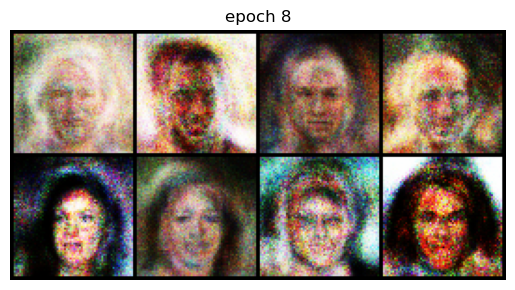

for epoch: 9/20... batch: 1... G-loss:1.2580006122589111.... D-loss: 0.6022700667381287
for epoch: 9/20... batch: 51... G-loss:1.0928869247436523.... D-loss: 0.5988059639930725
for epoch: 9/20... batch: 101... G-loss:1.1887307167053223.... D-loss: 0.5882916450500488
for epoch: 9/20... batch: 151... G-loss:1.34171724319458.... D-loss: 0.6053138971328735
for epoch: 9/20... batch: 201... G-loss:1.1953823566436768.... D-loss: 0.5792205333709717
for epoch: 9/20... batch: 251... G-loss:1.149543285369873.... D-loss: 0.6480973362922668
for epoch: 9/20... batch: 301... G-loss:1.0825064182281494.... D-loss: 0.6032605171203613
for epoch: 9/20... batch: 351... G-loss:1.1142387390136719.... D-loss: 0.5763489007949829
for epoch: 9/20... batch: 401... G-loss:1.117710828781128.... D-loss: 0.6098475456237793
for epoch: 9/20... batch: 451... G-loss:1.2304511070251465.... D-loss: 0.5820359587669373
for epoch: 9/20... batch: 501... G-loss:1.153266429901123.... D-loss: 0.6056885719299316
for epoch: 9/20...

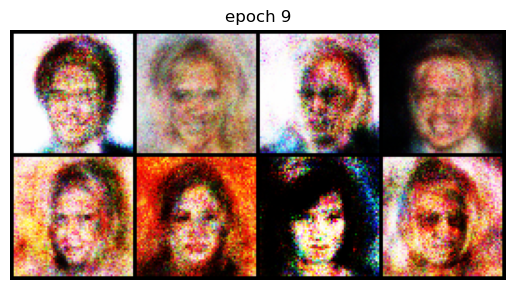

for epoch: 10/20... batch: 1... G-loss:1.1919325590133667.... D-loss: 0.5592715740203857
for epoch: 10/20... batch: 51... G-loss:1.1005728244781494.... D-loss: 0.6226512789726257
for epoch: 10/20... batch: 101... G-loss:1.1619188785552979.... D-loss: 0.6041020154953003
for epoch: 10/20... batch: 151... G-loss:1.035613775253296.... D-loss: 0.6217765808105469
for epoch: 10/20... batch: 201... G-loss:1.2202585935592651.... D-loss: 0.5769449472427368
for epoch: 10/20... batch: 251... G-loss:1.1617103815078735.... D-loss: 0.6512777209281921
for epoch: 10/20... batch: 301... G-loss:1.1505630016326904.... D-loss: 0.5933519601821899
for epoch: 10/20... batch: 351... G-loss:1.1745305061340332.... D-loss: 0.5821945667266846
for epoch: 10/20... batch: 401... G-loss:1.1086682081222534.... D-loss: 0.6088672280311584
for epoch: 10/20... batch: 451... G-loss:1.0727717876434326.... D-loss: 0.6040849089622498
for epoch: 10/20... batch: 501... G-loss:1.2123833894729614.... D-loss: 0.7095962166786194
for

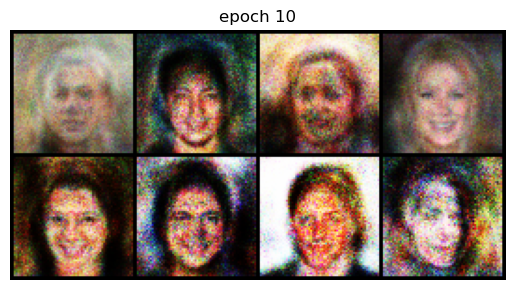

for epoch: 11/20... batch: 1... G-loss:1.177639365196228.... D-loss: 0.6313799023628235
for epoch: 11/20... batch: 51... G-loss:1.0687227249145508.... D-loss: 0.616429328918457
for epoch: 11/20... batch: 101... G-loss:1.1563606262207031.... D-loss: 0.6061091423034668
for epoch: 11/20... batch: 151... G-loss:1.1527791023254395.... D-loss: 0.632132887840271
for epoch: 11/20... batch: 201... G-loss:1.1382791996002197.... D-loss: 0.5972217321395874
for epoch: 11/20... batch: 251... G-loss:1.3374860286712646.... D-loss: 0.6180410385131836
for epoch: 11/20... batch: 301... G-loss:1.1172997951507568.... D-loss: 0.5886908769607544
for epoch: 11/20... batch: 351... G-loss:1.3010371923446655.... D-loss: 0.6088871955871582
for epoch: 11/20... batch: 401... G-loss:1.206021785736084.... D-loss: 0.5611095428466797
for epoch: 11/20... batch: 451... G-loss:1.147628903388977.... D-loss: 0.5779951810836792
for epoch: 11/20... batch: 501... G-loss:1.1749675273895264.... D-loss: 0.641084611415863
for epoc

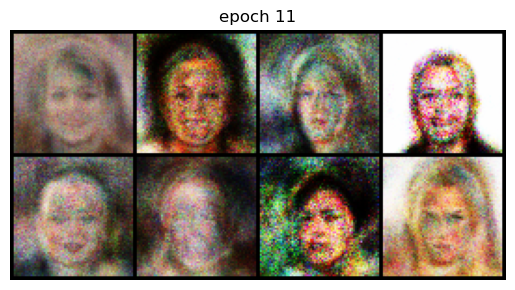

for epoch: 12/20... batch: 1... G-loss:1.1876325607299805.... D-loss: 0.6165353059768677
for epoch: 12/20... batch: 51... G-loss:1.0360901355743408.... D-loss: 0.6132321953773499
for epoch: 12/20... batch: 101... G-loss:1.1624698638916016.... D-loss: 0.6059068441390991
for epoch: 12/20... batch: 151... G-loss:1.0137295722961426.... D-loss: 0.6252691745758057
for epoch: 12/20... batch: 201... G-loss:1.1139352321624756.... D-loss: 0.6046653985977173
for epoch: 12/20... batch: 251... G-loss:1.1357479095458984.... D-loss: 0.5895907878875732
for epoch: 12/20... batch: 301... G-loss:1.11899995803833.... D-loss: 0.6045408844947815
for epoch: 12/20... batch: 351... G-loss:1.1256673336029053.... D-loss: 0.6209260821342468
for epoch: 12/20... batch: 401... G-loss:0.9980605840682983.... D-loss: 0.6459349989891052
for epoch: 12/20... batch: 451... G-loss:1.1326110363006592.... D-loss: 0.6144303679466248
for epoch: 12/20... batch: 501... G-loss:1.2344484329223633.... D-loss: 0.6145164370536804
for 

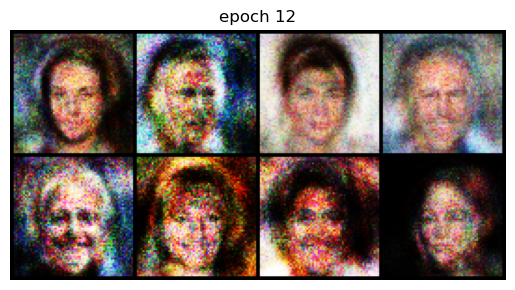

for epoch: 13/20... batch: 1... G-loss:1.1317898035049438.... D-loss: 0.6006662845611572
for epoch: 13/20... batch: 51... G-loss:1.0851235389709473.... D-loss: 0.6537694931030273
for epoch: 13/20... batch: 101... G-loss:1.0360511541366577.... D-loss: 0.6289767026901245
for epoch: 13/20... batch: 151... G-loss:1.1811655759811401.... D-loss: 0.6225993633270264
for epoch: 13/20... batch: 201... G-loss:1.0695286989212036.... D-loss: 0.6134514808654785
for epoch: 13/20... batch: 251... G-loss:1.1553821563720703.... D-loss: 0.6090793609619141
for epoch: 13/20... batch: 301... G-loss:1.0768070220947266.... D-loss: 0.5863091945648193
for epoch: 13/20... batch: 351... G-loss:1.051038146018982.... D-loss: 0.6423211693763733
for epoch: 13/20... batch: 401... G-loss:1.1168785095214844.... D-loss: 0.6790343523025513
for epoch: 13/20... batch: 451... G-loss:1.0860666036605835.... D-loss: 0.6082457304000854
for epoch: 13/20... batch: 501... G-loss:1.0973217487335205.... D-loss: 0.6205424070358276
for

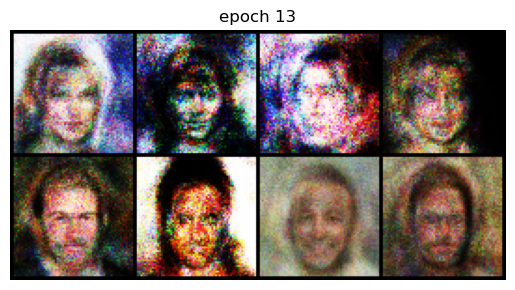

for epoch: 14/20... batch: 1... G-loss:1.1746770143508911.... D-loss: 0.6230672597885132
for epoch: 14/20... batch: 51... G-loss:1.1312320232391357.... D-loss: 0.5706151723861694
for epoch: 14/20... batch: 101... G-loss:1.096787929534912.... D-loss: 0.5987482666969299
for epoch: 14/20... batch: 151... G-loss:1.130908727645874.... D-loss: 0.6049128174781799
for epoch: 14/20... batch: 201... G-loss:1.1377363204956055.... D-loss: 0.5864602327346802
for epoch: 14/20... batch: 251... G-loss:1.1796324253082275.... D-loss: 0.5690829753875732
for epoch: 14/20... batch: 301... G-loss:1.12155020236969.... D-loss: 0.5988994836807251
for epoch: 14/20... batch: 351... G-loss:1.0840047597885132.... D-loss: 0.6176878809928894
for epoch: 14/20... batch: 401... G-loss:1.0245450735092163.... D-loss: 0.6048826575279236
for epoch: 14/20... batch: 451... G-loss:1.1274216175079346.... D-loss: 0.63231360912323
for epoch: 14/20... batch: 501... G-loss:1.1580718755722046.... D-loss: 0.5888810157775879
for epoc

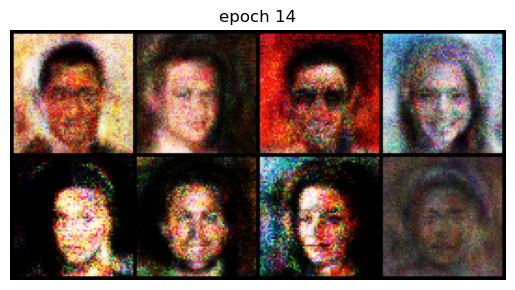

for epoch: 15/20... batch: 1... G-loss:1.1119155883789062.... D-loss: 0.6191874146461487
for epoch: 15/20... batch: 51... G-loss:1.1065993309020996.... D-loss: 0.578999400138855
for epoch: 15/20... batch: 101... G-loss:1.1692211627960205.... D-loss: 0.5702415108680725
for epoch: 15/20... batch: 151... G-loss:1.2047696113586426.... D-loss: 0.6252941489219666
for epoch: 15/20... batch: 201... G-loss:1.0841373205184937.... D-loss: 0.6120110750198364
for epoch: 15/20... batch: 251... G-loss:1.2059645652770996.... D-loss: 0.6226681470870972
for epoch: 15/20... batch: 301... G-loss:1.1464275121688843.... D-loss: 0.633023738861084
for epoch: 15/20... batch: 351... G-loss:1.1862331628799438.... D-loss: 0.6113404035568237
for epoch: 15/20... batch: 401... G-loss:1.0629117488861084.... D-loss: 0.6340450048446655
for epoch: 15/20... batch: 451... G-loss:1.1644729375839233.... D-loss: 0.6285300850868225
for epoch: 15/20... batch: 501... G-loss:1.0219998359680176.... D-loss: 0.625815749168396
for e

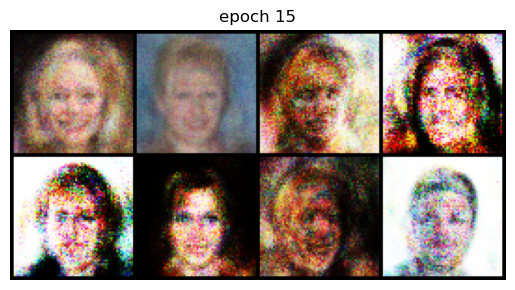

for epoch: 16/20... batch: 1... G-loss:1.127791404724121.... D-loss: 0.6189923286437988
for epoch: 16/20... batch: 51... G-loss:1.130339503288269.... D-loss: 0.5967561602592468
for epoch: 16/20... batch: 101... G-loss:1.1604619026184082.... D-loss: 0.6259621381759644
for epoch: 16/20... batch: 151... G-loss:1.0841809511184692.... D-loss: 0.641318678855896
for epoch: 16/20... batch: 201... G-loss:1.1296131610870361.... D-loss: 0.6111542582511902
for epoch: 16/20... batch: 251... G-loss:1.268668532371521.... D-loss: 0.5989644527435303
for epoch: 16/20... batch: 301... G-loss:1.1040668487548828.... D-loss: 0.6111982464790344
for epoch: 16/20... batch: 351... G-loss:1.023855447769165.... D-loss: 0.6345838308334351
for epoch: 16/20... batch: 401... G-loss:1.0929583311080933.... D-loss: 0.6022475361824036
for epoch: 16/20... batch: 451... G-loss:1.053951621055603.... D-loss: 0.6339195966720581
for epoch: 16/20... batch: 501... G-loss:1.2062759399414062.... D-loss: 0.6748045682907104
for epoc

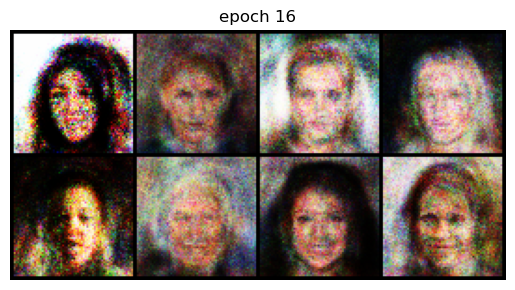

for epoch: 17/20... batch: 1... G-loss:1.168548345565796.... D-loss: 0.5840492844581604
for epoch: 17/20... batch: 51... G-loss:1.236321210861206.... D-loss: 0.5913606882095337
for epoch: 17/20... batch: 101... G-loss:1.1833226680755615.... D-loss: 0.5871529579162598
for epoch: 17/20... batch: 151... G-loss:1.1025429964065552.... D-loss: 0.6199769973754883
for epoch: 17/20... batch: 201... G-loss:1.1360321044921875.... D-loss: 0.600257933139801
for epoch: 17/20... batch: 251... G-loss:1.14689040184021.... D-loss: 0.6331823468208313
for epoch: 17/20... batch: 301... G-loss:1.0444155931472778.... D-loss: 0.6164668202400208
for epoch: 17/20... batch: 351... G-loss:1.132968544960022.... D-loss: 0.600495457649231
for epoch: 17/20... batch: 401... G-loss:1.0645047426223755.... D-loss: 0.5809118151664734
for epoch: 17/20... batch: 451... G-loss:1.065439224243164.... D-loss: 0.5885483026504517
for epoch: 17/20... batch: 501... G-loss:1.0669305324554443.... D-loss: 0.6253422498703003
for epoch:

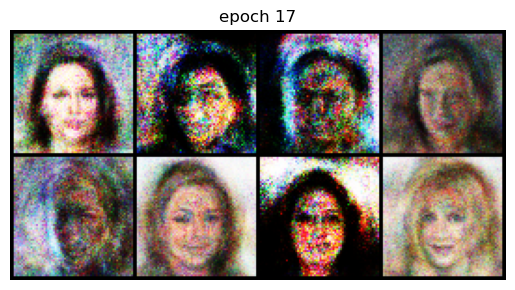

for epoch: 18/20... batch: 1... G-loss:1.1749728918075562.... D-loss: 0.5854790806770325
for epoch: 18/20... batch: 51... G-loss:1.2077805995941162.... D-loss: 0.5698931217193604
for epoch: 18/20... batch: 101... G-loss:1.2166149616241455.... D-loss: 0.6759592294692993
for epoch: 18/20... batch: 151... G-loss:1.181323528289795.... D-loss: 0.6259620189666748
for epoch: 18/20... batch: 201... G-loss:1.0887267589569092.... D-loss: 0.6313730478286743
for epoch: 18/20... batch: 251... G-loss:1.1329174041748047.... D-loss: 0.6254174113273621
for epoch: 18/20... batch: 301... G-loss:0.9826955795288086.... D-loss: 0.5975620746612549
for epoch: 18/20... batch: 351... G-loss:1.105987548828125.... D-loss: 0.6319836974143982
for epoch: 18/20... batch: 401... G-loss:1.1173324584960938.... D-loss: 0.6133410334587097
for epoch: 18/20... batch: 451... G-loss:1.1507234573364258.... D-loss: 0.6182391047477722
for epoch: 18/20... batch: 501... G-loss:1.0884604454040527.... D-loss: 0.6231074333190918
for 

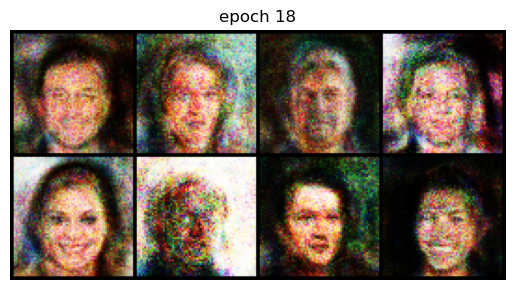

for epoch: 19/20... batch: 1... G-loss:1.105975866317749.... D-loss: 0.6048784852027893
for epoch: 19/20... batch: 51... G-loss:1.0810701847076416.... D-loss: 0.5987403988838196
for epoch: 19/20... batch: 101... G-loss:1.1054226160049438.... D-loss: 0.6139779686927795
for epoch: 19/20... batch: 151... G-loss:1.159311294555664.... D-loss: 0.5805550813674927
for epoch: 19/20... batch: 201... G-loss:1.1097655296325684.... D-loss: 0.6446483731269836
for epoch: 19/20... batch: 251... G-loss:1.1728034019470215.... D-loss: 0.6351370811462402
for epoch: 19/20... batch: 301... G-loss:1.0635201930999756.... D-loss: 0.6092355251312256
for epoch: 19/20... batch: 351... G-loss:1.001610279083252.... D-loss: 0.64765465259552
for epoch: 19/20... batch: 401... G-loss:1.075822114944458.... D-loss: 0.6400018334388733
for epoch: 19/20... batch: 451... G-loss:1.2526463270187378.... D-loss: 0.576935350894928
for epoch: 19/20... batch: 501... G-loss:1.1195623874664307.... D-loss: 0.5822309255599976
for epoch

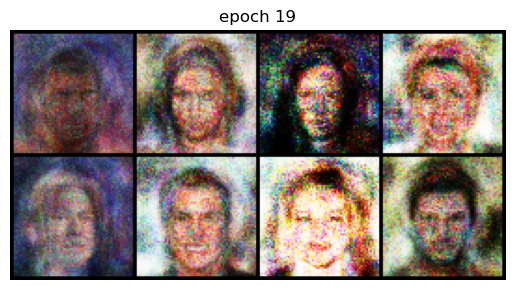

for epoch: 20/20... batch: 1... G-loss:1.193781852722168.... D-loss: 0.5831479430198669
for epoch: 20/20... batch: 51... G-loss:1.0438849925994873.... D-loss: 0.636974036693573
for epoch: 20/20... batch: 101... G-loss:1.1509729623794556.... D-loss: 0.552130937576294
for epoch: 20/20... batch: 151... G-loss:1.1265814304351807.... D-loss: 0.5763037204742432
for epoch: 20/20... batch: 201... G-loss:1.0943193435668945.... D-loss: 0.6265885233879089
for epoch: 20/20... batch: 251... G-loss:1.1127393245697021.... D-loss: 0.6307972073554993
for epoch: 20/20... batch: 301... G-loss:1.1486859321594238.... D-loss: 0.5574233531951904
for epoch: 20/20... batch: 351... G-loss:1.069966435432434.... D-loss: 0.6500333547592163
for epoch: 20/20... batch: 401... G-loss:1.0820571184158325.... D-loss: 0.6034406423568726
for epoch: 20/20... batch: 451... G-loss:1.0791988372802734.... D-loss: 0.6027357578277588
for epoch: 20/20... batch: 501... G-loss:1.0360636711120605.... D-loss: 0.6117821931838989
for ep

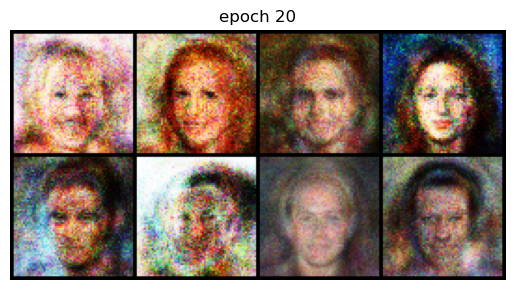

In [18]:
train(generator, discriminator, dataloader, epochs=20)

In [17]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Laptop GPU
